1. Import library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

2. Buat nama kolom

In [2]:
columns = [
    "unit_number", "time_cycle",
    "setting_1", "setting_2", "setting_3",
    "sensor_1", "sensor_2", "sensor_3", "sensor_4", "sensor_5",
    "sensor_6", "sensor_7", "sensor_8", "sensor_9", "sensor_10",
    "sensor_11", "sensor_12", "sensor_13", "sensor_14", "sensor_15",
    "sensor_16", "sensor_17", "sensor_18", "sensor_19", "sensor_20",
    "sensor_21"
]

3. Baca file FD001

In [4]:
train = pd.read_csv(
    "train_FD001.txt",
    sep=r"\s+",
    header=None,
    names=columns
)

test = pd.read_csv(
    "test_FD001.txt",
    sep=r"\s+",
    header=None,
    names=columns
)

rul = pd.read_csv(
    "RUL_FD001.txt",
    sep=r"\s+",
    header=None,
    names=["RUL"]
)

4. Cek ukuran data

In [5]:
print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("RUL shape:", rul.shape)

Train shape: (20631, 26)
Test shape: (13096, 26)
RUL shape: (100, 1)


In [6]:
train.head()

,unit_number,time_cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


5. Cek jumlah mesin

In [7]:
print("Jumlah engine pada train:", train["unit_number"].nunique())
print("Jumlah engine pada test:", test["unit_number"].nunique())

Jumlah engine pada train: 100
Jumlah engine pada test: 100


6. Cek missing values

In [8]:
train.isnull().sum()

,0
unit_number,0
time_cycle,0
setting_1,0
setting_2,0
setting_3,0
sensor_1,0
sensor_2,0
sensor_3,0
sensor_4,0
sensor_5,0


#4. Hitung RUL untuk training data

In [9]:
max_cycle = train.groupby("unit_number")["time_cycle"].max().reset_index()
max_cycle.columns = ["unit_number", "max_cycle"]

train = train.merge(max_cycle, on="unit_number", how="left")
train["RUL"] = train["max_cycle"] - train["time_cycle"]

train[["unit_number", "time_cycle", "max_cycle", "RUL"]].head(10)

,unit_number,time_cycle,max_cycle,RUL
0,1,1,192,191
1,1,2,192,190
2,1,3,192,189
3,1,4,192,188
4,1,5,192,187
5,1,6,192,186
6,1,7,192,185
7,1,8,192,184
8,1,9,192,183
9,1,10,192,182


#5. Buat visualisasi awal

Grafik RUL mesin pertama

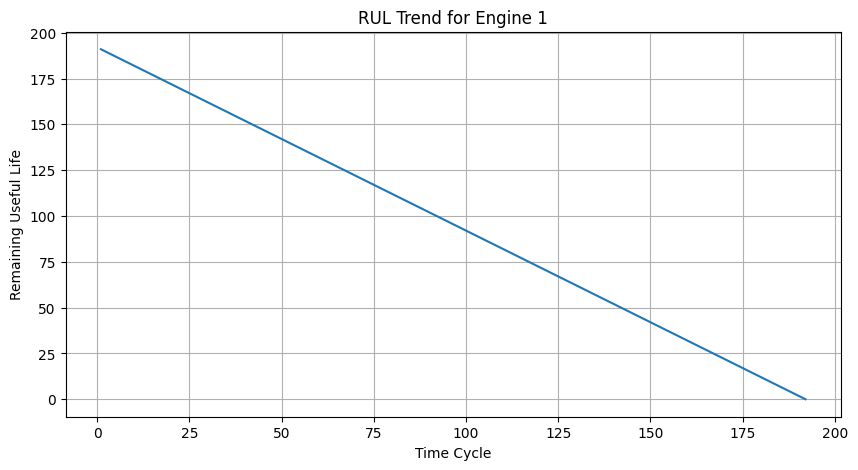

In [10]:
engine_1 = train[train["unit_number"] == 1]

plt.figure(figsize=(10, 5))
plt.plot(engine_1["time_cycle"], engine_1["RUL"])
plt.xlabel("Time Cycle")
plt.ylabel("Remaining Useful Life")
plt.title("RUL Trend for Engine 1")
plt.grid(True)
plt.show()

Grafik salah satu sensor

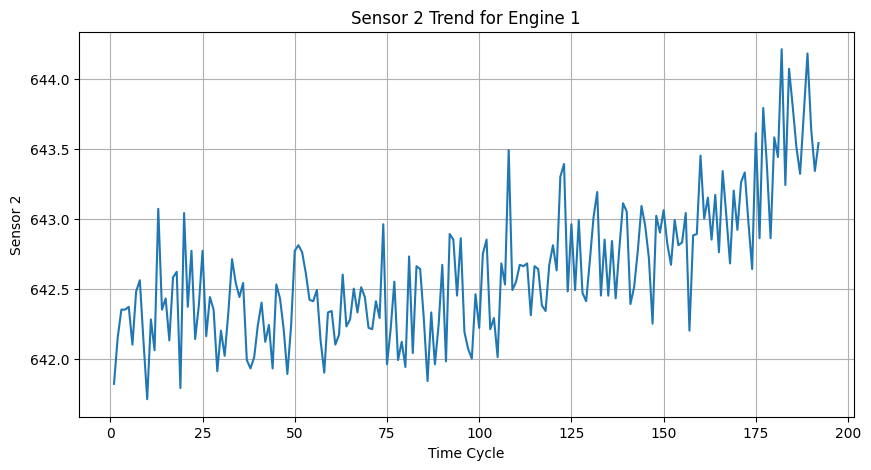

In [11]:
plt.figure(figsize=(10, 5))
plt.plot(engine_1["time_cycle"], engine_1["sensor_2"])
plt.xlabel("Time Cycle")
plt.ylabel("Sensor 2")
plt.title("Sensor 2 Trend for Engine 1")
plt.grid(True)
plt.show()